# Phase 2: HuggingFace & Transformers
**Author:** Faisal  
**Goal:** Master the modern NLP stack — Attention → Transformers → Fine-tuning → RAG  

## Phase Roadmap
- Day 09: Attention Mechanism from Scratch
- Day 10: HuggingFace Pipelines
- Day 11: Tokenizers Deep Dive
- Day 12: Fine-tuning BERT
- Day 13: NLP Evaluation Metrics
- Day 14: Sentence Transformers & Embeddings
- Day 15: LoRA & PEFT
- Day 16: Project — NLP Multi-Tool App

---
# Day 09 — Attention Mechanism from Scratch
**Key Question:** Why did transformers replace LSTMs?  
**What we build:** Single-head attention + Positional Encoding in pure NumPy

In [6]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("All imports ready. No GPU needed today — pure NumPy.")

NumPy version: 2.0.2
All imports ready. No GPU needed today — pure NumPy.


## Step 1: The Softmax Function
Before attention, we need softmax — it converts raw scores into probabilities that sum to 1.

In [7]:
def softmax(x):
    # WHY subtract max first?
    # e^1000 causes overflow (infinity). Subtracting max keeps numbers small.
    # The final result is mathematically identical — try proving it yourself.
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

# Test it on a simple example first
raw_scores = np.array([2.0, 1.0, 0.5])
probabilities = softmax(raw_scores)

print("Raw scores:   ", raw_scores)
print("After softmax:", np.round(probabilities, 3))
print("Sum:          ", np.round(probabilities.sum(), 4))

Raw scores:    [2.  1.  0.5]
After softmax: [0.629 0.231 0.14 ]
Sum:           1.0


## Step 2: Single-Head Attention
Q = Query (what am I looking for?)
K = Key (what do I contain?)
V = Value (what do I actually return?)

In [8]:
def single_head_attention(Q, K, V):
    d_k = Q.shape[-1]
    
    # Step 1: How similar is each Query to each Key?
    scores = Q @ K.T                    # (seq_len, seq_len)
    
    # Step 2: Scale — WHY? Large d_k → large dot products → softmax saturates
    scores = scores / np.sqrt(d_k)
    
    # Step 3: Convert scores to probabilities
    weights = softmax(scores)           # (seq_len, seq_len)
    
    # Step 4: Weighted blend of Values
    output = weights @ V                # (seq_len, d_v)
    
    return output, weights

# --- Build a tiny 3-token sequence ---
np.random.seed(42)
seq_len = 3       # "The  cat  sat"
d_model = 8       # embedding size

# These represent token embeddings (normally learned, we random-init here)
embeddings = np.random.randn(seq_len, d_model)

# Three separate weight matrices — ALL learned during training
# WHY separate? Each projects the same embedding into a different role
W_Q = np.random.randn(d_model, d_model)
W_K = np.random.randn(d_model, d_model)
W_V = np.random.randn(d_model, d_model)

# Project: same embedding, three different perspectives
Q = embeddings @ W_Q    # "what am I searching for?"
K = embeddings @ W_K    # "what do I offer to others?"
V = embeddings @ W_V    # "what do I actually give when selected?"

output, attention_weights = single_head_attention(Q, K, V)

print("Tokens:          ['The', 'cat', 'sat']")
print("Input shape:     ", embeddings.shape)
print("Output shape:    ", output.shape)
print("\nAttention weights:")
print(np.round(attention_weights, 3))
print("\nEach row sums to:", np.round(attention_weights.sum(axis=-1), 3))

Tokens:          ['The', 'cat', 'sat']
Input shape:      (3, 8)
Output shape:     (3, 8)

Attention weights:
[[0.012 0.984 0.004]
 [0.    0.    1.   ]
 [0.145 0.765 0.09 ]]

Each row sums to: [1. 1. 1.]


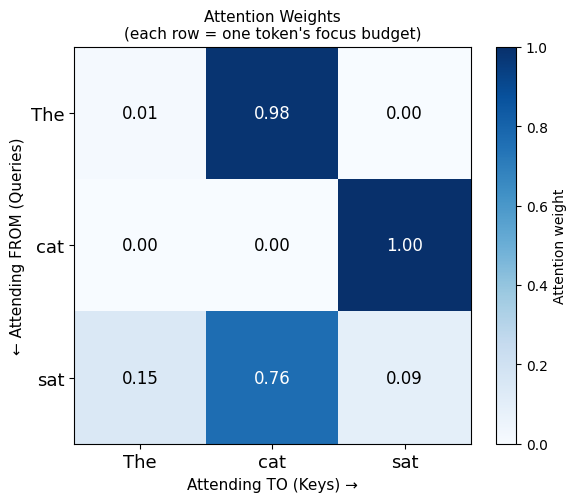

In [9]:
tokens = ["The", "cat", "sat"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attention_weights, cmap='Blues')

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, fontsize=13)
ax.set_yticklabels(tokens, fontsize=13)
ax.set_xlabel("Attending TO (Keys) →", fontsize=11)
ax.set_ylabel("← Attending FROM (Queries)", fontsize=11)
ax.set_title("Attention Weights\n(each row = one token's focus budget)", fontsize=11)

for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax.text(j, i, f'{attention_weights[i, j]:.2f}',
                ha='center', va='center', fontsize=12,
                color='white' if attention_weights[i, j] > 0.5 else 'black')

plt.colorbar(im, label="Attention weight")
plt.tight_layout()
plt.show()

## Step 3: Positional Encoding
WHY: Attention is completely order-blind.
"cat sat The" and "The cat sat" produce identical attention — 
the same tokens, same dot products, same weights.
We need to inject position information BEFORE attention runs.

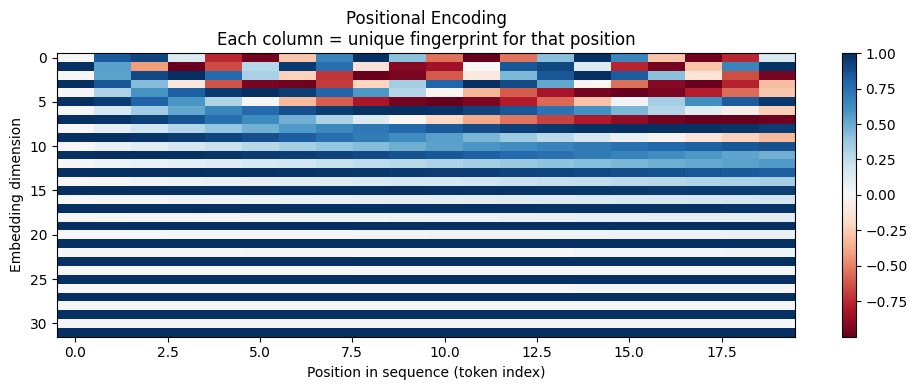

Shape: (20, 32)

Position 0 (first token): [0. 1. 0. 1. 0. 1. 0. 1.]
Position 1 (second token): [0.841 0.54  0.533 0.846 0.311 0.95  0.177 0.984]
Position 2 (third token):  [ 0.909 -0.416  0.902  0.431  0.591  0.807  0.348  0.937]

Are any two rows identical? False


In [10]:
def positional_encoding(seq_len, d_model):
    """
    WHY sinusoids and not just 0, 1, 2?
    
    If we used raw positions (0, 1, 2...), position 100 would be 
    100x larger than position 1 — dominating the embedding completely.
    
    Sinusoids stay bounded between -1 and 1 regardless of position.
    Also: the model can compute RELATIVE positions from sin/cos values
    using trig identities — something raw integers can't give you.
    """
    PE = np.zeros((seq_len, d_model))
    
    positions = np.arange(seq_len)[:, np.newaxis]      # (seq_len, 1)
    dims = np.arange(0, d_model, 2)[np.newaxis, :]     # (1, d_model/2)
    
    div_term = 10000 ** (dims / d_model)
    
    # Even dimensions → sine wave
    PE[:, 0::2] = np.sin(positions / div_term)
    # Odd dimensions → cosine wave (offset by 90°, gives more signal variety)
    PE[:, 1::2] = np.cos(positions / div_term)
    
    return PE

# Visualize it
pe = positional_encoding(seq_len=20, d_model=32)

plt.figure(figsize=(10, 4))
plt.imshow(pe.T, cmap='RdBu', aspect='auto')
plt.colorbar()
plt.xlabel("Position in sequence (token index)")
plt.ylabel("Embedding dimension")
plt.title("Positional Encoding\nEach column = unique fingerprint for that position")
plt.tight_layout()
plt.show()

print("Shape:", pe.shape)
print("\nPosition 0 (first token):", np.round(pe[0, :8], 3))
print("Position 1 (second token):", np.round(pe[1, :8], 3))
print("Position 2 (third token): ", np.round(pe[2, :8], 3))
print("\nAre any two rows identical?", 
      any(np.allclose(pe[i], pe[j]) 
          for i in range(20) for j in range(20) if i != j))

## Step 4: Full Pipeline — Embeddings + Position + Attention

1. Token embeddings shape: (6, 16)
2. After adding position info: (6, 16)
3. Attention output shape: (6, 16)


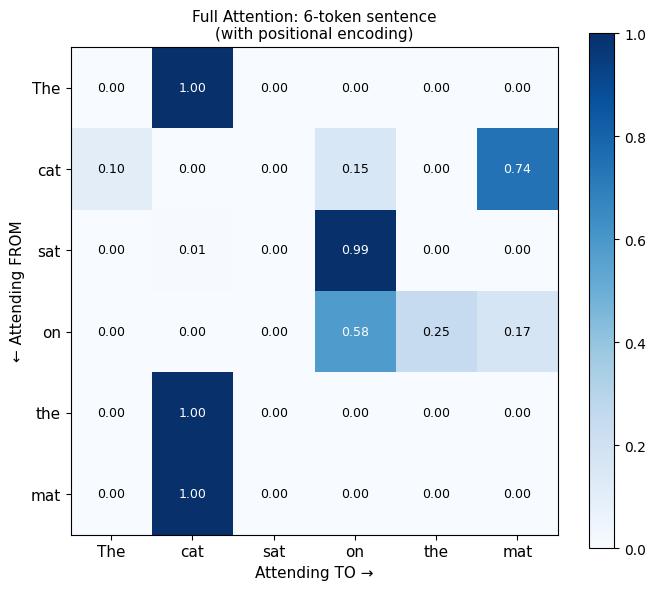


Day 9 Complete.
What you built: softmax → single-head attention → positional encoding → full pipeline
What you understand: WHY each piece exists, not just HOW to code it


In [11]:
# Full Day 9 pipeline in one place
np.random.seed(42)

tokens = ["The", "cat", "sat", "on", "the", "mat"]
seq_len = len(tokens)
d_model = 16

# Step 1: Token embeddings (random here, learned in real transformers)
embeddings = np.random.randn(seq_len, d_model)
print("1. Token embeddings shape:", embeddings.shape)

# Step 2: Add positional encoding
pe = positional_encoding(seq_len, d_model)
embeddings_with_pos = embeddings + pe
print("2. After adding position info:", embeddings_with_pos.shape)

# Step 3: Project to Q, K, V
W_Q = np.random.randn(d_model, d_model)
W_K = np.random.randn(d_model, d_model)
W_V = np.random.randn(d_model, d_model)

Q = embeddings_with_pos @ W_Q
K = embeddings_with_pos @ W_K
V = embeddings_with_pos @ W_V

# Step 4: Run attention
output, weights = single_head_attention(Q, K, V)
print("3. Attention output shape:", output.shape)

# Visualize final attention
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(weights, cmap='Blues')
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels(tokens, fontsize=11)
ax.set_yticklabels(tokens, fontsize=11)
ax.set_xlabel("Attending TO →", fontsize=11)
ax.set_ylabel("← Attending FROM", fontsize=11)
ax.set_title("Full Attention: 6-token sentence\n(with positional encoding)", fontsize=11)

for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f'{weights[i,j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if weights[i,j] > 0.5 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.show()

print("\nDay 9 Complete.")
print("What you built: softmax → single-head attention → positional encoding → full pipeline")
print("What you understand: WHY each piece exists, not just HOW to code it")

---
# Day 10 — HuggingFace Hub & Pipelines
**Goal:** Run 5 NLP tasks using pipeline() — understand what's happening under the hood  
**Key Question:** What does pipeline() actually do that we're not seeing?

In [12]:
# HuggingFace transformers comes pre-installed on Kaggle
# But let's verify and import
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

print("HuggingFace Transformers ready.")
print("Today we run 5 NLP tasks. Each one downloads a pretrained model.")
print("First run = slow (downloading). Second run = fast (cached).")

HuggingFace Transformers ready.
Today we run 5 NLP tasks. Each one downloads a pretrained model.
First run = slow (downloading). Second run = fast (cached).


## Task 1: Sentiment Analysis
Model: DistilBERT fine-tuned on SST-2 (Stanford Sentiment Treebank)
WHY this model: Lighter than BERT, 97% of BERT's accuracy, 60% faster

In [13]:
# First pipeline — sentiment analysis
sentiment = pipeline("sentiment-analysis")

# Test on different inputs
texts = [
    "I absolutely loved this movie, it was fantastic!",
    "This was the worst experience of my life.",
    "The food was okay, nothing special.",
    "I can't believe how amazing this product is!"
]

print("=" * 55)
print("TASK 1: SENTIMENT ANALYSIS")
print("=" * 55)

for text in texts:
    result = sentiment(text)[0]
    print(f"\nText:  {text}")
    print(f"Label: {result['label']}")
    print(f"Score: {result['score']:.4f}")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

TASK 1: SENTIMENT ANALYSIS

Text:  I absolutely loved this movie, it was fantastic!
Label: POSITIVE
Score: 0.9999

Text:  This was the worst experience of my life.
Label: NEGATIVE
Score: 0.9998

Text:  The food was okay, nothing special.
Label: NEGATIVE
Score: 0.9834

Text:  I can't believe how amazing this product is!
Label: POSITIVE
Score: 0.9998


## Task 2: Named Entity Recognition (NER)
NER = identify and classify real-world entities in text
Entities: Person, Organization, Location, Date, etc.
WHY useful: Information extraction, knowledge graphs, search engines

In [14]:
ner = pipeline("ner", model="dbmdz/bert-large-cased-finetuned-conll03-english",
               aggregation_strategy="simple")

texts = [
    "Elon Musk founded SpaceX in Hawthorne, California in 2002.",
    "Virat Kohli scored 100 runs for India against Australia in Mumbai.",
    "Apple was founded by Steve Jobs and Steve Wozniak in Cupertino."
]

print("=" * 55)
print("TASK 2: NAMED ENTITY RECOGNITION")
print("=" * 55)

for text in texts:
    print(f"\nText: {text}")
    entities = ner(text)
    print("Entities found:")
    for entity in entities:
        print(f"  '{entity['word']}' → {entity['entity_group']} "
              f"(confidence: {entity['score']:.3f})")

config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

TASK 2: NAMED ENTITY RECOGNITION

Text: Elon Musk founded SpaceX in Hawthorne, California in 2002.
Entities found:
  'Elon Musk' → PER (confidence: 0.999)
  'SpaceX' → ORG (confidence: 0.999)
  'Hawthorne' → LOC (confidence: 0.991)
  'California' → LOC (confidence: 0.998)

Text: Virat Kohli scored 100 runs for India against Australia in Mumbai.
Entities found:
  'Virat Kohli' → PER (confidence: 0.996)
  'India' → LOC (confidence: 1.000)
  'Australia' → LOC (confidence: 1.000)
  'Mumbai' → LOC (confidence: 0.999)

Text: Apple was founded by Steve Jobs and Steve Wozniak in Cupertino.
Entities found:
  'Apple' → ORG (confidence: 0.999)
  'Steve Jobs' → PER (confidence: 0.990)
  'Steve Wozniak' → PER (confidence: 0.889)
  'Cupertino' → LOC (confidence: 0.968)


## Task 3: Summarization
Model: facebook/bart-large-cnn (BART fine-tuned on CNN/DailyMail news)
WHY BART: Encoder-decoder architecture — encoder reads, decoder writes summary
WHEN to use: Long documents → short summaries
WHEN NOT to use: Short texts (nothing to compress), technical docs (hallucination risk)

In [15]:
from transformers import BartForConditionalGeneration, BartTokenizer

# Load model and tokenizer directly — more explicit, more control
model_name = "facebook/bart-large-cnn"
tokenizer = BartTokenizer.from_pretrained(model_name)
model = BartForConditionalGeneration.from_pretrained(model_name)

article = """
Artificial intelligence is transforming the way doctors diagnose diseases. 
Researchers at Stanford University have developed a new AI system that can 
detect early signs of Alzheimer's disease from brain scans with 95% accuracy, 
compared to 83% accuracy achieved by experienced radiologists. The system was 
trained on over 10,000 MRI scans from patients across 15 countries. 
However, experts caution that AI should assist doctors, not replace them. 
The technology still struggles with rare variants of the disease and performs 
poorly on scans from older imaging equipment. Clinical trials are planned 
for 2026 across 50 hospitals in the United States and Europe. 
The researchers estimate the tool could reduce diagnosis time from 
several weeks to under 48 hours.
"""

print("=" * 55)
print("TASK 3: SUMMARIZATION")
print("=" * 55)
print(f"Original length: {len(article.split())} words")

# Tokenize
inputs = tokenizer(article, 
                   return_tensors="pt", 
                   max_length=1024, 
                   truncation=True)

# Generate summary
# do_sample=False → deterministic (same output every run)
# do_sample=True  → random sampling (different output every run)
summary_ids = model.generate(inputs["input_ids"],
                             max_length=80,
                             min_length=30,
                             do_sample=False)

summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print(f"Summary length: {len(summary.split())} words")
print(f"\nSummary:\n{summary}")
compression = (1 - len(summary.split())/len(article.split())) * 100
print(f"\nCompression: {compression:.1f}% shorter")

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

TASK 3: SUMMARIZATION
Original length: 116 words
Summary length: 36 words

Summary:
Stanford University has developed a new AI system that can detect early signs of Alzheimer's disease from brain scans with 95% accuracy. The system was trained on over 10,000 MRI scans from patients across 15 countries.

Compression: 69.0% shorter


## Task 4: Extractive Question Answering
NOT generative — the model extracts the answer span directly from the context
It cannot answer questions whose answers aren't in the provided text
Model: deepset/roberta-base-squad2 (fine-tuned on SQuAD2)

In [16]:
qa = pipeline("question-answering",
              model="deepset/roberta-base-squad2")

context = """
The Indian Space Research Organisation (ISRO) successfully launched 
Chandrayaan-3 on July 14, 2023. The mission achieved a historic soft landing 
near the lunar south pole on August 23, 2023, making India the fourth country 
to land on the Moon and the first to land near the south pole. 
The lander was named Vikram and the rover was named Pragyan. 
The mission cost approximately 615 crore rupees, making it one of the 
most cost-effective lunar missions in history. The rover operated for 
14 Earth days before entering sleep mode as the lunar night began.
"""

questions = [
    "When did Chandrayaan-3 land on the Moon?",
    "What was the name of the rover?",
    "How much did the mission cost?",
    "Who is the CEO of ISRO?"  # Answer not in context — watch what happens
]

print("=" * 55)
print("TASK 4: QUESTION ANSWERING")
print("=" * 55)

for question in questions:
    result = qa(question=question, context=context)
    print(f"\nQ: {question}")
    print(f"A: {result['answer']}")
    print(f"Confidence: {result['score']:.4f}")

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

TASK 4: QUESTION ANSWERING

Q: When did Chandrayaan-3 land on the Moon?
A: August 23, 2023
Confidence: 0.6066

Q: What was the name of the rover?
A: Pragyan
Confidence: 0.9613

Q: How much did the mission cost?
A: 615 crore rupees
Confidence: 0.6892

Q: Who is the CEO of ISRO?
A: 

Confidence: 0.0000


## Task 5: Zero-Shot Classification
The most powerful pipeline — classify text into ANY categories
WITHOUT training on those categories.
Model: facebook/bart-large-mnli (trained on Natural Language Inference)
WHY it works: NLI teaches "does this text entail this label?"

In [17]:
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli")

# Same text, THREE completely different classification schemes
text = "The patient experienced severe chest pain and was rushed to the ICU."

# Scheme 1: Topic classification
labels_1 = ["medical emergency", "sports", "technology", "politics"]

# Scheme 2: Sentiment/urgency
labels_2 = ["urgent", "routine", "low priority"]

# Scheme 3: Department routing
labels_3 = ["cardiology", "neurology", "orthopedics", "general medicine"]

print("=" * 55)
print("TASK 5: ZERO-SHOT CLASSIFICATION")
print("=" * 55)
print(f"\nText: {text}\n")

for scheme_name, labels in [("Topic", labels_1), 
                             ("Urgency", labels_2),
                             ("Department", labels_3)]:
    result = classifier(text, candidate_labels=labels)
    print(f"--- {scheme_name} Classification ---")
    for label, score in zip(result['labels'], result['scores']):
        bar = "█" * int(score * 30)
        print(f"{label:20} {score:.3f} {bar}")
    print()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

TASK 5: ZERO-SHOT CLASSIFICATION

Text: The patient experienced severe chest pain and was rushed to the ICU.

--- Topic Classification ---
medical emergency    0.974 █████████████████████████████
technology           0.014 
sports               0.007 
politics             0.005 

--- Urgency Classification ---
urgent               0.973 █████████████████████████████
low priority         0.021 
routine              0.005 

--- Department Classification ---
cardiology           0.887 ██████████████████████████
neurology            0.057 █
general medicine     0.032 
orthopedics          0.024 



## Day 10 Reflections

### What pipeline() actually does:
1. Downloads pretrained model from HuggingFace Hub
2. Loads the tokenizer for that model
3. Tokenizes your input text
4. Runs model inference
5. Post-processes raw output into human-readable results

### Key lessons:
- Always specify model name in production — never use defaults
- Know your model's label space before deploying
- Know your training dataset — it determines real-world behavior
- SQuAD2 vs SQuAD1 = answerable vs unanswerable questions
- Zero-shot = NLI reframing, not magic



---
# Day 11 — Tokenizers Deep Dive
**Key Question:** What exactly happens to my text before the model sees it?
**What we build:** Tokenize text manually, inspect every piece, understand attention masks

In [18]:
from transformers import BertTokenizer, GPT2Tokenizer, AutoTokenizer

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

print("Both tokenizers loaded.")
print(f"BERT vocabulary size: {bert_tokenizer.vocab_size:,}")
print(f"GPT2 vocabulary size: {gpt2_tokenizer.vocab_size:,}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Both tokenizers loaded.
BERT vocabulary size: 30,522
GPT2 vocabulary size: 50,257


## Part 1: What Does BERT Actually See?

In [19]:
text = "I am learning transformers at HuggingFace!"

# Step 1: Basic tokenization
tokens = bert_tokenizer.tokenize(text)
print("=" * 55)
print("STEP 1: RAW TOKENS")
print("=" * 55)
print(f"Original text : {text}")
print(f"Tokens        : {tokens}")
print(f"Token count   : {len(tokens)}")

# Step 2: Convert to IDs
token_ids = bert_tokenizer.convert_tokens_to_ids(tokens)
print(f"\nToken IDs     : {token_ids}")

# Step 3: Full encoding — what model actually receives
encoded = bert_tokenizer(text)
print("\n" + "=" * 55)
print("STEP 2: FULL ENCODING (what model sees)")
print("=" * 55)
print(f"input_ids       : {encoded['input_ids']}")
print(f"attention_mask  : {encoded['attention_mask']}")
print(f"token_type_ids  : {encoded['token_type_ids']}")

# Step 4: Decode back — prove it's lossless
decoded = bert_tokenizer.decode(encoded['input_ids'])
print(f"\nDecoded back  : {decoded}")

STEP 1: RAW TOKENS
Original text : I am learning transformers at HuggingFace!
Tokens        : ['i', 'am', 'learning', 'transformers', 'at', 'hugging', '##face', '!']
Token count   : 8

Token IDs     : [1045, 2572, 4083, 19081, 2012, 17662, 12172, 999]

STEP 2: FULL ENCODING (what model sees)
input_ids       : [101, 1045, 2572, 4083, 19081, 2012, 17662, 12172, 999, 102]
attention_mask  : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
token_type_ids  : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Decoded back  : [CLS] i am learning transformers at huggingface! [SEP]


In [20]:
# Batch two sentences of different lengths
sentences = [
    "I love NLP",
    "Transformers are the foundation of modern AI systems"
]

# padding=True → pad shorter to match longer
# truncation=True → cut if too long
batch = bert_tokenizer(
    sentences,
    padding=True,
    truncation=True,
    max_length=20,
    return_tensors="pt"  # return PyTorch tensors
)

print("=" * 55)
print("BATCHED ENCODING — TWO SENTENCES")
print("=" * 55)

print("\ninput_ids:")
print(batch['input_ids'])

print("\nattention_mask:")
print(batch['attention_mask'])

print("\nShapes:")
print(f"input_ids shape    : {batch['input_ids'].shape}")
print(f"attention_mask shape: {batch['attention_mask'].shape}")

# Decode both to see padding clearly
print("\nDecoded sentence 1:", bert_tokenizer.decode(batch['input_ids'][0]))
print("Decoded sentence 2:", bert_tokenizer.decode(batch['input_ids'][1]))

BATCHED ENCODING — TWO SENTENCES

input_ids:
tensor([[  101,  1045,  2293, 17953,  2361,   102,     0,     0,     0,     0],
        [  101, 19081,  2024,  1996,  3192,  1997,  2715,  9932,  3001,   102]])

attention_mask:
tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

Shapes:
input_ids shape    : torch.Size([2, 10])
attention_mask shape: torch.Size([2, 10])

Decoded sentence 1: [CLS] i love nlp [SEP] [PAD] [PAD] [PAD] [PAD]
Decoded sentence 2: [CLS] transformers are the foundation of modern ai systems [SEP]


## Part 2: BPE vs WordPiece — BERT vs GPT2

In [21]:
texts = [
    "I am learning transformers at HuggingFace!",
    "tokenization",
    "unhappiness",
    "faisalimam",          # your name — not in any vocabulary
    "COVID-19 pandemic",   # modern word
]

print("=" * 55)
print("BPE (GPT2) vs WordPiece (BERT) COMPARISON")
print("=" * 55)

for text in texts:
    bert_tokens = bert_tokenizer.tokenize(text)
    gpt2_tokens = gpt2_tokenizer.tokenize(text)
    
    print(f"\nText: '{text}'")
    print(f"BERT  ({len(bert_tokens):2d} tokens): {bert_tokens}")
    print(f"GPT2  ({len(gpt2_tokens):2d} tokens): {gpt2_tokens}")

BPE (GPT2) vs WordPiece (BERT) COMPARISON

Text: 'I am learning transformers at HuggingFace!'
BERT  ( 8 tokens): ['i', 'am', 'learning', 'transformers', 'at', 'hugging', '##face', '!']
GPT2  (10 tokens): ['I', 'Ġam', 'Ġlearning', 'Ġtransform', 'ers', 'Ġat', 'ĠHug', 'ging', 'Face', '!']

Text: 'tokenization'
BERT  ( 2 tokens): ['token', '##ization']
GPT2  ( 2 tokens): ['token', 'ization']

Text: 'unhappiness'
BERT  ( 4 tokens): ['un', '##ha', '##pp', '##iness']
GPT2  ( 3 tokens): ['un', 'h', 'appiness']

Text: 'faisalimam'
BERT  ( 4 tokens): ['fai', '##sal', '##ima', '##m']
GPT2  ( 4 tokens): ['fa', 'isal', 'im', 'am']

Text: 'COVID-19 pandemic'
BERT  ( 7 tokens): ['co', '##vid', '-', '19', 'pan', '##de', '##mic']
GPT2  ( 6 tokens): ['CO', 'VID', '-', '19', 'Ġpand', 'emic']


## Part 3: Truncation — The Silent Data Killer
The most dangerous tokenizer behavior — it silently cuts your text.

In [22]:
# BERT's maximum sequence length is 512 tokens
# What happens when your text is longer?

long_text = """
Artificial intelligence has been transforming industries across the globe. 
From healthcare to finance, from education to transportation, AI systems 
are being deployed at unprecedented scale. Large language models trained 
on billions of parameters have demonstrated remarkable capabilities in 
natural language understanding and generation. However, these systems 
also come with significant challenges including hallucination, bias, 
and the requirement for massive computational resources. Researchers 
are actively working on solutions including retrieval augmented generation, 
constitutional AI, and efficient fine-tuning methods like LoRA and QLoRA.
The field is moving at an extraordinary pace with new breakthroughs 
being announced every week. Understanding these systems requires both 
theoretical knowledge and practical hands-on experience with real models.
""" * 5  # repeat 5 times to make it very long

# WITHOUT truncation
tokens_no_trunc = bert_tokenizer.tokenize(long_text)

# WITH truncation at 512
encoded_trunc = bert_tokenizer(
    long_text,
    truncation=True,
    max_length=512,
    return_tensors="pt"
)

print("=" * 55)
print("TRUNCATION — THE SILENT DATA KILLER")
print("=" * 55)
print(f"Original text length : {len(long_text.split())} words")
print(f"Full token count     : {len(tokens_no_trunc)} tokens")
print(f"After truncation     : {encoded_trunc['input_ids'].shape[1]} tokens")
print(f"Tokens LOST          : {len(tokens_no_trunc) - encoded_trunc['input_ids'].shape[1]}")

lost_pct = (1 - 512/len(tokens_no_trunc)) * 100
print(f"Percentage lost      : {lost_pct:.1f}%")

print("\n⚠️  WARNING: Truncation is SILENT.")
print("The model never tells you it cut your text.")
print("Always check: len(tokenizer.tokenize(text)) < max_length")

Token indices sequence length is longer than the specified maximum sequence length for this model (670 > 512). Running this sequence through the model will result in indexing errors


TRUNCATION — THE SILENT DATA KILLER
Original text length : 550 words
Full token count     : 670 tokens
After truncation     : 512 tokens
Tokens LOST          : 158
Percentage lost      : 23.6%

⚠️  WARNING: Truncation is SILENT.
The model never tells you it cut your text.
Always check: len(tokenizer.tokenize(text)) < max_length


## Part 4: Edge Cases — What Breaks In The Real World

In [23]:
edge_cases = {
    "Empty string"        : "",
    "Only spaces"         : "     ",
    "Numbers"             : "The price is 1234567.89",
    "Hindi text"          : "मैं मशीन लर्निंग सीख रहा हूं",
    "Code"                : "def forward(self, x): return self.layer(x)",
    "Emojis"              : "I love AI 🤖🧠💡",
    "Very long word"      : "supercalifragilisticexpialidocious",
    "Mixed languages"     : "Hello नमस्ते Bonjour",
}

print("=" * 55)
print("EDGE CASES — WHAT BREAKS IN PRODUCTION")
print("=" * 55)

for case_name, text in edge_cases.items():
    try:
        tokens = bert_tokenizer.tokenize(text) if text.strip() else ["(empty)"]
        token_count = len(tokens)
        has_unk = '[UNK]' in tokens
        
        print(f"\n{case_name}:")
        print(f"  Input  : '{text[:50]}'")
        print(f"  Tokens : {tokens[:8]}{'...' if len(tokens) > 8 else ''}")
        print(f"  Count  : {token_count} | Has [UNK]: {has_unk}")
    except Exception as e:
        print(f"\n{case_name}: ERROR — {e}")

EDGE CASES — WHAT BREAKS IN PRODUCTION

Empty string:
  Input  : ''
  Tokens : ['(empty)']
  Count  : 1 | Has [UNK]: False

Only spaces:
  Input  : '     '
  Tokens : ['(empty)']
  Count  : 1 | Has [UNK]: False

Numbers:
  Input  : 'The price is 1234567.89'
  Tokens : ['the', 'price', 'is', '123', '##45', '##6', '##7', '.']...
  Count  : 9 | Has [UNK]: False

Hindi text:
  Input  : 'मैं मशीन लर्निंग सीख रहा हूं'
  Tokens : ['म', 'म', '##श', '##ी', '##न', 'ल', '##र', '##न']...
  Count  : 17 | Has [UNK]: False

Code:
  Input  : 'def forward(self, x): return self.layer(x)'
  Tokens : ['def', 'forward', '(', 'self', ',', 'x', ')', ':']...
  Count  : 15 | Has [UNK]: False

Emojis:
  Input  : 'I love AI 🤖🧠💡'
  Tokens : ['i', 'love', 'ai', '[UNK]']
  Count  : 4 | Has [UNK]: True

Very long word:
  Input  : 'supercalifragilisticexpialidocious'
  Tokens : ['super', '##cal', '##if', '##rag', '##ilis', '##tic', '##ex', '##pia']...
  Count  : 11 | Has [UNK]: False

Mixed languages:
  Input  : 'Hel

## Day 11 Reflections

### What tokenization actually does:
Text → subword pieces → integer IDs → model input

### Three things I now understand that I didn't before:
1. [CLS] is not just a start marker — it becomes the sentence representation used for classification
2. attention_mask is not about attention weights — it tells the model which tokens are real vs padding
3. Truncation is silent — 23.6% of data can vanish without any warning

### BERT vs GPT2 tokenization difference:
- BERT: WordPiece, lowercase, ## prefix, 30k vocab, 512 max
- GPT2: BPE, case-sensitive, Ġ space marker, 50k vocab, 1024 max

### Edge case I'll remember:
Emojis → [UNK]. Hindi → character-level explosion. Numbers → no numeric understanding.

### What this means for Day 12 fine-tuning:
Before touching the Trainer API, always inspect your tokenized data first.

---
# Day 12 — Fine-tuning BERT for Sentiment Classification
**Dataset:** Sentiment140 (tweets)
**Model:** bert-base-uncased
**Goal:** Fine-tune → evaluate F1 → push to HuggingFace Hub
**Why this matters:** This single task appears in junior AI engineer interviews

In [1]:
# Verify GPU is available
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import load_dataset
import numpy as np
from sklearn.metrics import f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print("\nAll imports ready.")

GPU available: True
Device: Tesla T4

All imports ready.


## Step 1: Load Dataset
Using Sentiment140 — 1.6 million tweets, labeled 0 (negative) or 4 (positive)
We sample 20,000 for fast training — enough to see real results on a T4

In [3]:
# Load IMDB dataset — 25k train, 25k test, fully supported
dataset = load_dataset("imdb")

print("Dataset loaded:")
print(dataset)
print("\nColumn names:", dataset['train'].column_names)
print("\nFirst example:")
print("Text:", dataset['train'][0]['text'][:200])
print("Label:", dataset['train'][0]['label'], "(0=negative, 1=positive)")
print("\nDataset size:")
print(f"Train: {len(dataset['train']):,} examples")
print(f"Test:  {len(dataset['test']):,} examples")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset loaded:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Column names: ['text', 'label']

First example:
Text: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev
Label: 0 (0=negative, 1=positive)

Dataset size:
Train: 25,000 examples
Test:  25,000 examples


## Step 2: Sample & Tokenize
We take 20k from train and 5k from test — enough for real results, fast enough for T4

In [4]:
# Sample for faster training
from datasets import DatasetDict

small_dataset = DatasetDict({
    'train': dataset['train'].shuffle(seed=42).select(range(20000)),
    'test':  dataset['test'].shuffle(seed=42).select(range(5000))
})

print("Sampled dataset:")
print(small_dataset)

# Check label balance — CRITICAL before any fine-tuning
train_labels = small_dataset['train']['label']
pos = sum(train_labels)
neg = len(train_labels) - pos
print(f"\nLabel balance (train):")
print(f"  Positive: {pos:,} ({pos/len(train_labels)*100:.1f}%)")
print(f"  Negative: {neg:,} ({neg/len(train_labels)*100:.1f}%)")

Sampled dataset:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 5000
    })
})

Label balance (train):
  Positive: 9,954 (49.8%)
  Negative: 10,046 (50.2%)


## Step 3: Tokenize the Dataset
Apply BERT tokenizer to every example — this is what Day 11 prepared you for

In [5]:
# Load BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',    # pad all to same length
        truncation=True,         # cut at max_length (silent — we know this now)
        max_length=256           # IMDB reviews are long — 256 is a balance
    )

# Apply to entire dataset at once — much faster than looping
print("Tokenizing dataset... (this takes ~1 minute)")
tokenized_dataset = small_dataset.map(
    tokenize_function,
    batched=True,               # process in batches — faster
    remove_columns=['text']     # remove raw text — model doesn't need it
)

print("\nTokenization complete.")
print("Features now:", tokenized_dataset['train'].features)
print("Train shape:", tokenized_dataset['train'].shape)
print("Test shape: ", tokenized_dataset['test'].shape)

# Quick sanity check — look at one tokenized example
print("\nSample input_ids (first 20 tokens):")
print(tokenized_dataset['train'][0]['input_ids'][:20])
print("Sample attention_mask (first 20):")
print(tokenized_dataset['train'][0]['attention_mask'][:20])
print("Label:", tokenized_dataset['train'][0]['label'])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing dataset... (this takes ~1 minute)


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]


Tokenization complete.
Features now: {'label': ClassLabel(names=['neg', 'pos']), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}
Train shape: (20000, 4)
Test shape:  (5000, 4)

Sample input_ids (first 20 tokens):
[101, 2045, 2003, 2053, 7189, 2012, 2035, 2090, 3481, 3771, 1998, 6337, 2099, 2021, 1996, 2755, 2008, 2119, 2024, 2610]
Sample attention_mask (first 20):
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Label: 1


## Step 4: Load Model + Define Metrics
bert-base-uncased + classification head on top of [CLS] token

In [6]:
from sklearn.metrics import f1_score
import numpy as np

# Load BERT with a classification head
# num_labels=2 → adds a linear layer: hidden_size(768) → 2 outputs
model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size:           ~{total_params * 4 / 1024**2:.0f} MB")

# Define evaluation metric
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    f1 = f1_score(labels, predictions, average='weighted')
    accuracy = (predictions == labels).mean()
    
    return {
        'f1': round(f1, 4),
        'accuracy': round(accuracy, 4)
    }

print("\nModel and metrics ready.")
print("Classification head added on top of [CLS] token representation.")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     109,483,778
Trainable parameters: 109,483,778
Model size:           ~418 MB

Model and metrics ready.
Classification head added on top of [CLS] token representation.


## Step 5: Train with HuggingFace Trainer API
Trainer handles: training loop, evaluation, checkpointing, logging
What took 100 lines in Phase 1 now takes 20 lines

In [7]:
training_args = TrainingArguments(
    output_dir='./bert-imdb',
    
    # Training duration
    num_train_epochs=3,
    
    # Batch sizes — T4 can handle 16 comfortably at max_length=256
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    
    # Optimizer settings
    learning_rate=2e-5,        # CRITICAL — too high destroys pretrained weights
    weight_decay=0.01,         # L2 regularization
    warmup_ratio=0.1,          # warm up LR for first 10% of steps
    
    # Evaluation strategy
    eval_strategy='epoch',     # evaluate after every epoch
    save_strategy='epoch',     # save checkpoint after every epoch
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    
    # Logging
    logging_steps=100,
    report_to='none',          # disable wandb
    
    # Reproducibility
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['test'],
    compute_metrics=compute_metrics,
)

print("Trainer ready. Starting training...")
print(f"Total training examples: {len(tokenized_dataset['train']):,}")
print(f"Batch size:              {training_args.per_device_train_batch_size}")
print(f"Steps per epoch:         {len(tokenized_dataset['train']) // training_args.per_device_train_batch_size}")
print(f"Total steps:             {len(tokenized_dataset['train']) // training_args.per_device_train_batch_size * training_args.num_train_epochs}")
print("\nEstimated time: ~15-20 minutes on T4")
print("Watch the loss drop across epochs...")

# START TRAINING
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready. Starting training...
Total training examples: 20,000
Batch size:              16
Steps per epoch:         1250
Total steps:             3750

Estimated time: ~15-20 minutes on T4
Watch the loss drop across epochs...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.499057,0.428018,0.910700,0.910800
2,0.338041,0.423606,0.921000,0.921000
3,0.189974,0.583884,0.918800,0.918800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1875, training_loss=0.4039026601155599, metrics={'train_runtime': 1653.4207, 'train_samples_per_second': 36.288, 'train_steps_per_second': 1.134, 'total_flos': 7893331660800000.0, 'train_loss': 0.4039026601155599, 'epoch': 3.0})

## Step 6: Final Evaluation + Error Analysis

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions on test set
print("Running final evaluation...")
predictions = trainer.predict(tokenized_dataset['test'])

logits = predictions.predictions
labels = predictions.label_ids
preds = np.argmax(logits, axis=-1)

# Full classification report
print("\n" + "=" * 55)
print("FINAL EVALUATION RESULTS")
print("=" * 55)
print(classification_report(labels, preds, 
                            target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(labels, preds)
print("Confusion Matrix:")
print(f"                 Predicted Neg  Predicted Pos")
print(f"Actual Negative:     {cm[0][0]:4d}           {cm[0][1]:4d}")
print(f"Actual Positive:     {cm[1][0]:4d}           {cm[1][1]:4d}")

# Error analysis — look at what the model got wrong
print("\n" + "=" * 55)
print("ERROR ANALYSIS — 5 Wrong Predictions")
print("=" * 55)

wrong_indices = np.where(preds != labels)[0]
label_names = ['NEGATIVE', 'POSITIVE']

for idx in wrong_indices[:5]:
    # Decode tokens back to text
    input_ids = tokenized_dataset['test'][int(idx)]['input_ids']
    text = tokenizer.decode(input_ids, skip_special_tokens=True)
    print(f"\nExample {idx}:")
    print(f"  Text (first 150 chars): {text[:150]}")
    print(f"  True label:  {label_names[labels[idx]]}")
    print(f"  Predicted:   {label_names[preds[idx]]}")
    print(f"  Confidence:  {float(torch.softmax(torch.tensor(logits[idx]), dim=0).max()):.3f}")

Running final evaluation...



FINAL EVALUATION RESULTS
              precision    recall  f1-score   support

    Negative       0.93      0.91      0.92      2494
    Positive       0.91      0.93      0.92      2506

    accuracy                           0.92      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.92      0.92      0.92      5000

Confusion Matrix:
                 Predicted Neg  Predicted Pos
Actual Negative:     2271            223
Actual Positive:      173           2333

ERROR ANALYSIS — 5 Wrong Predictions

Example 21:
  Text (first 150 chars): coming from kiarostami, this art - house visual and sound exposition is a surprise. for a director known for his narratives and keen observation of hu
  True label:  NEGATIVE
  Predicted:   POSITIVE
  Confidence:  0.860

Example 75:
  Text (first 150 chars): a truly masterful piece of filmmaking. it managed to put me to sleep and to boggle my mind. so boring that it induces sleep and yet so ludicrous that 
  True label: 

## Step 7: Push to HuggingFace Hub
Making our fine-tuned model publicly available with a model card

In [10]:
from huggingface_hub import login

# Paste your HuggingFace token here
HF_TOKEN = "use your own😉"
login(token=HF_TOKEN)

# Your HuggingFace username
HF_USERNAME = "your_hf_username"
MODEL_NAME = f"(use your own😉)/bert-imdb-sentiment"

print(f"Pushing model to: {MODEL_NAME}")

# Push model and tokenizer
model.push_to_hub(MODEL_NAME)
tokenizer.push_to_hub(MODEL_NAME)

print("\nModel pushed successfully!")
print(f"View at: https://huggingface.co/{MODEL_NAME}")

Pushing model to: faisalimam19/bert-imdb-sentiment


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]


Model pushed successfully!
View at: https://huggingface.co/faisalimam19/bert-imdb-sentiment


## Step 8: Test Our Published Model
Loading our own model from HuggingFace Hub — exactly how anyone else would use it

In [11]:
from transformers import pipeline

# Load YOUR model from HF Hub — same way anyone in the world would use it
classifier = pipeline(
    "sentiment-analysis",
    model="faisalimam19/bert-imdb-sentiment"
)

# Test on real reviews
test_reviews = [
    "This movie was absolutely fantastic. Best film I've seen all year.",
    "Terrible waste of time. Boring, predictable, and poorly acted.",
    "A truly masterful piece of filmmaking. It managed to put me to sleep.",  # sarcasm
    "The first half was dreadful but the ending completely redeemed it.",      # mixed
    "I can't believe how amazing this movie was. I loved every minute!",
    "Not the worst movie ever made, but close enough.",                        # negative framing
]

print("=" * 55)
print("TESTING OUR FINE-TUNED MODEL")
print(f"Model: huggingface.co/faisalimam19/bert-imdb-sentiment")
print("=" * 55)

for review in test_reviews:
    result = classifier(review)[0]
    label = result['label']
    score = result['score']
    bar = "█" * int(score * 20)
    print(f"\nReview: {review[:70]}...")
    print(f"Result: {label} ({score:.3f}) {bar}")

config.json:   0%|          | 0.00/815 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

TESTING OUR FINE-TUNED MODEL
Model: huggingface.co/faisalimam19/bert-imdb-sentiment

Review: This movie was absolutely fantastic. Best film I've seen all year....
Result: LABEL_1 (0.994) ███████████████████

Review: Terrible waste of time. Boring, predictable, and poorly acted....
Result: LABEL_0 (0.991) ███████████████████

Review: A truly masterful piece of filmmaking. It managed to put me to sleep....
Result: LABEL_1 (0.992) ███████████████████

Review: The first half was dreadful but the ending completely redeemed it....
Result: LABEL_0 (0.990) ███████████████████

Review: I can't believe how amazing this movie was. I loved every minute!...
Result: LABEL_1 (0.994) ███████████████████

Review: Not the worst movie ever made, but close enough....
Result: LABEL_0 (0.934) ██████████████████


In [12]:
# Fix label names on the hub
from huggingface_hub import HfApi

api = HfApi()

# Update model config with proper label names
model.config.id2label = {0: "NEGATIVE", 1: "POSITIVE"}
model.config.label2id = {"NEGATIVE": 0, "POSITIVE": 1}

# Push updated config
model.push_to_hub("faisalimam19/bert-imdb-sentiment")
print("Labels fixed. Model updated on Hub.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Labels fixed. Model updated on Hub.


In [13]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="faisalimam19/bert-imdb-sentiment"
)

test_reviews = [
    # Clear cases
    "RRR is one of the greatest action films ever made. Absolutely breathtaking.",
    "3 Idiots changed my perspective on education. A masterpiece of Indian cinema.",
    
    # Sarcasm
    "Oh great, another superhero movie. Just what the world needed.",
    "Brilliant. Two hours of my life I'll never get back.",
    
    # Mixed
    "The cinematography was stunning but the story made no sense whatsoever.",
    "Great acting, terrible script. I wanted to love it but couldn't.",
    
    # Negative framing
    "Not as bad as everyone said, but still pretty unwatchable.",
    "I've seen worse, but not by much.",
    
    # Subtle
    "A bold creative choice. Not for everyone, but certainly memorable.",
    "The director clearly had a vision. Whether it worked is another question.",
]

print("=" * 55)
print("TESTING — BOLLYWOOD + TRICKY REVIEWS")
print("=" * 55)

for review in test_reviews:
    result = classifier(review)[0]
    label = result['label']
    score = result['score']
    bar = "█" * int(score * 20)
    print(f"\nReview: {review[:70]}")
    print(f"Result: {label} ({score:.3f}) {bar}")

config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

TESTING — BOLLYWOOD + TRICKY REVIEWS

Review: RRR is one of the greatest action films ever made. Absolutely breathta
Result: POSITIVE (0.996) ███████████████████

Review: 3 Idiots changed my perspective on education. A masterpiece of Indian 
Result: POSITIVE (0.988) ███████████████████

Review: Oh great, another superhero movie. Just what the world needed.
Result: POSITIVE (0.865) █████████████████

Review: Brilliant. Two hours of my life I'll never get back.
Result: POSITIVE (0.957) ███████████████████

Review: The cinematography was stunning but the story made no sense whatsoever
Result: NEGATIVE (0.991) ███████████████████

Review: Great acting, terrible script. I wanted to love it but couldn't.
Result: NEGATIVE (0.994) ███████████████████

Review: Not as bad as everyone said, but still pretty unwatchable.
Result: NEGATIVE (0.514) ██████████

Review: I've seen worse, but not by much.
Result: NEGATIVE (0.534) ██████████

Review: A bold creative choice. Not for everyone, but certainly

TODO: Retrain with Sarcasm Headlines Dataset mixed into IMDB
TODO: Try roberta-base as base model — compare F1